In [2]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. LOAD DATASET
file_path = "dataset_tugas1_preprocessing.csv"
df = pd.read_csv(file_path)


# 2. EKSPLORASI AWAL (EDA)
print("--- Info Data ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Statistik ---")
print(df.describe(include='all'))

# 3. MENANGANI MISSING VALUES
df["Umur"] = df["Umur"].fillna(df["Umur"].median())
df["Nilai_Akhir"] = df["Nilai_Akhir"].fillna(df["Nilai_Akhir"].mode()[0])

# 4. NORMALISASI FORMAT TANGGAL
df["Tanggal_Ujian"] = pd.to_datetime(df["Tanggal_Ujian"], errors="coerce")

# 5. ENCODING LABEL
kolom_kat = ["Nama", "Jenis_Kelamin", "Prodi", "Status", "Nilai_Akhir"]
encoders = {}
for col in kolom_kat:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le


# 6. SPLIT DATA (80% Latih - 20% Uji)
X = df.drop(columns=["Status", "Tanggal_Ujian"])
y = df["Status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nUkuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Uji: {X_test.shape}")

--- Info Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB

--- Missing Values ---
ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64

--- Statistik ---
           ID Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
count      99   99            99               99     99          70   
unique     99   10          

/tmp/ipykernel_4945/2043125497.py:27: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Tanggal_Ujian"] = pd.to_datetime(df["Tanggal_Ujian"], errors="coerce")


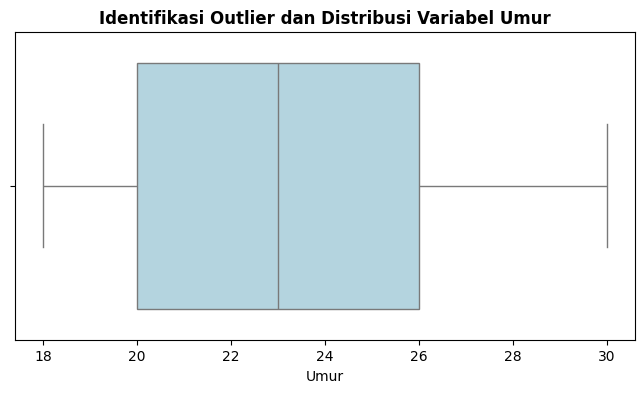

Mean Umur   : 23.333333333333332
Median Umur : 23.0


In [3]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Umur"], color="lightblue")

plt.title("Identifikasi Outlier dan Distribusi Variabel Umur", fontsize=12, fontweight="bold")
plt.xlabel("Umur")
plt.show()

# 2. Cek Statistik Skewness & Nilai
print("Mean Umur   :", df["Umur"].mean())
print("Median Umur :", df["Umur"].median())

# 3. Lakukan Fillna dengan Median
df["Umur"] = df["Umur"].fillna(df["Umur"].median())

/tmp/ipykernel_870/1942613743.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Prodi", ax=axes[1], palette="Blues_d")
/tmp/ipykernel_870/1942613743.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(prodi_labels, rotation=20, ha="right")


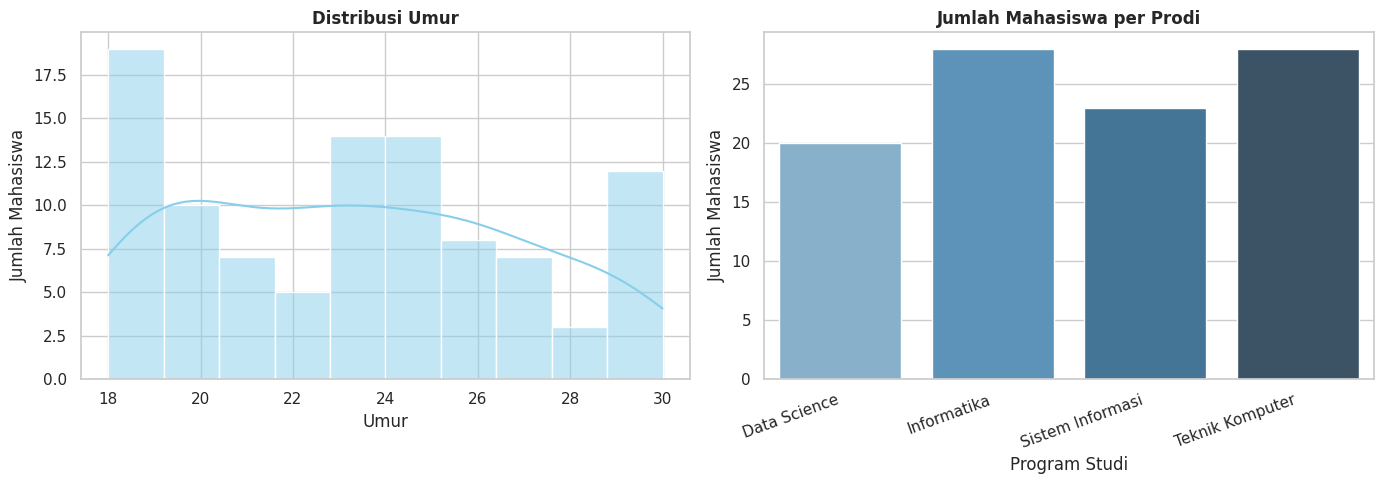

In [ ]:

# 7. VISUALISASI (PERBAIKAN KETERANGAN PRODI)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram Umur
sns.histplot(df["Umur"], kde=True, ax=axes[0], color="skyblue", bins=10)
axes[0].set_title("Distribusi Umur", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Umur")
axes[0].set_ylabel("Jumlah Mahasiswa")

# 2. Barplot Jumlah Mahasiswa per Prodi (Menggunakan Nama Asli Prodi)
prodi_labels = encoders["Prodi"].inverse_transform(sorted(df["Prodi"].unique()))

sns.countplot(data=df, x="Prodi", ax=axes[1], palette="Blues_d")
axes[1].set_title("Jumlah Mahasiswa per Prodi", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Program Studi")
axes[1].set_ylabel("Jumlah Mahasiswa")

# Mengganti angka 0, 1, 2... dengan nama Prodi & memiringkan label
axes[1].set_xticklabels(prodi_labels, rotation=20, ha="right")

plt.tight_layout()
plt.show()